# 02 · M0 explained — one US bond unit, step by step

## Executive summary (read this first)

M0 is the organizers' baseline. Every leaderboard score is "our score ÷ M0's score", so it pays to know exactly what it
does. This notebook builds M0 by hand on one unit, **t2-F1-greater-confidence-2024**: the **US 2-year Treasury yield
(UST_2Y)**, as of 2024-01-31, at horizons **126 and 189 business days**.

M0 in six steps:

1. **History:** the last 300 rows of the yield, up to the as-of date.
2. **Steps:** each day's change (today − yesterday), dropping a change that spans a long gap in the data.
3. **Fit:** the **mean step** `mu` (the drift) and the **variance of the steps** `sigma²`.
4. **Centre at horizon h:** `last value + h × mu`.
5. **Spread at horizon h:** variance `h × sigma²`; the two horizons are linked by covariance `min(h1, h2) × sigma²`
   (one path: day 189 is reached through day 126).
6. **Draws:** 500 draws from that normal distribution, with a fixed random seed per unit.

At the end, the hand-built draws are compared with `m0_baseline.draws`, the team's exact rebuild of M0: they are the same
numbers. The recipe is `docs/M0-BASELINE.md`.

## 0 — Setup and the card

In [1]:
import pathlib, sys, tomllib, zlib
import numpy as np, pandas as pd, pyarrow.parquet as pq
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_experiment_v3" else pathlib.Path.cwd() / "model_experiment_v3"
REPO = HERE.parent
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
import m0_baseline as m0
pd.set_option("display.float_format", lambda x: f"{x:.6g}")

UNIT = REPO / "units" / "t2-F1-greater-confidence-2024"
card = tomllib.loads((UNIT / "card.toml").read_text())
unit_id = card["task"]["id"]
asset = card["targets"]["asset_ids"][0]
horizons = [int(h) for h in card["targets"]["horizons"]]
asof = card["provenance"]["data_cutoff"]
print(f"unit {unit_id} | asset {asset} | horizons {horizons} business days | as-of {asof} | "
      f"target {card['targets']['target_type']} ({card['targets'].get('value_unit')})")

unit t2-F1-greater-confidence-2024 | asset UST_2Y | horizons [126, 189] business days | as-of 2024-01-31 | target level (percent_per_annum)


## 1 — History: the last 300 rows up to the as-of

M0 reads the first panel file (in name order) that holds the asset, keeps the rows on or before the as-of date, and takes
the **last 300**.

In [2]:
for path in sorted(UNIT.glob("*.parquet")):
    panel = pq.read_table(path).to_pandas()
    if asset in set(panel["asset"].astype(str)):
        break
print("panel file:", path.name)

hist = (panel[(panel["asset"].astype(str) == asset) & (panel["date"].astype(str).str[:10] <= asof)]
        .assign(date=lambda d: d["date"].astype(str).str[:10])[["date", "value"]]
        .dropna().sort_values(["date", "value"]).tail(300).reset_index(drop=True))
print(f"{len(hist)} rows, {hist.date.iloc[0]} to {hist.date.iloc[-1]}")
hist.tail(5)

panel file: rates_daily.parquet
300 rows, 2022-11-18 to 2024-01-31


,date,value
295,2024-01-25,4.28
296,2024-01-26,4.34
297,2024-01-29,4.29
298,2024-01-30,4.36
299,2024-01-31,4.27


## 2 — Steps: each day's change

`step = today's value − yesterday's value`. The **gap rule**: a change that spans more than `max(10 × the median gap,
5 days)` is dropped, so a hole in the data does not count as one big move. On a daily panel the median gap is 1 day,
so only a change across more than 10 calendar days is dropped.

In [3]:
dates = pd.to_datetime(hist.date)
gap_days = dates.diff().dt.days
limit = max(10 * gap_days.iloc[1:].median(), 5)
steps = pd.DataFrame({"date": hist.date, "value": hist.value, "step": hist.value.diff(), "gap (days)": gap_days})
steps = steps.iloc[1:]                                    # the first row has no yesterday
dropped = steps[steps["gap (days)"] > limit]
steps = steps[steps["gap (days)"] <= limit]
print(f"median gap {gap_days.iloc[1:].median():.0f} day(s) -> a change over more than {limit:.0f} days is dropped: {len(dropped)} dropped")
print(f"{len(steps)} steps")
steps.tail(5)

median gap 1 day(s) -> a change over more than 10 days is dropped: 0 dropped
299 steps


,date,value,step,gap (days)
295,2024-01-25,4.28,-0.06,1
296,2024-01-26,4.34,0.06,1
297,2024-01-29,4.29,-0.05,3
298,2024-01-30,4.36,0.07,1
299,2024-01-31,4.27,-0.09,1


## 3 — Fit: the mean step and the variance of the steps

- `mu` = the mean of the steps: the **drift**, the average daily change.
- `sigma²` = the variance of the steps (numpy's `cov`, dividing by n − 1); `sigma` = their sd.

That is the whole fit: two numbers.

In [5]:
x = steps["step"].to_numpy()
mu = x.mean()
sigma2 = float(np.cov(x))
print(f"n      = {len(x)} steps")
print(f"mu     = {mu:+.6f}   (mean daily change, percentage points)")
print(f"sigma2 = {sigma2:.8f}  -> sigma = {np.sqrt(sigma2):.6f}  (typical daily change)")

n      = 299 steps
mu     = -0.000803   (mean daily change, percentage points)
sigma2 = 0.00835976  -> sigma = 0.091432  (typical daily change)


## 4 — Predict the centre at each horizon

`centre(h) = last value + h × mu`. M0 walks the drift forward for `h` business days.

In [6]:
last = hist.value.iloc[-1]
centre = {h: last + h * mu for h in horizons}
for h in horizons:
    print(f"h = {h}: centre = {last:.4f} + {h} x ({mu:+.6f}) = {last:.4f} {h * mu:+.4f} = {centre[h]:.4f}")

h = 126: centre = 4.2700 + 126 x (-0.000803) = 4.2700 -0.1011 = 4.1689
h = 189: centre = 4.2700 + 189 x (-0.000803) = 4.2700 -0.1517 = 4.1183


## 5 — Predict the spread, and how the two horizons are linked

- variance at `h` = `h × sigma²`, so sd at `h` = `sigma × √h` (independent daily steps add their variances);
- covariance between the two horizons = `min(h1, h2) × sigma²` = `126 × sigma²`: one path, day 189 is reached through
  day 126, so they share the first 126 days.

As a 2 × 2 matrix (cells: UST_2Y at 126, UST_2Y at 189):

In [7]:
h1, h2 = horizons
cov = np.array([[min(h1, h1) * sigma2, min(h1, h2) * sigma2],
                [min(h2, h1) * sigma2, min(h2, h2) * sigma2]])
print("covariance matrix =\n", cov.round(6))
for h in horizons:
    print(f"sd at h = {h}: sqrt({h} x {sigma2:.8f}) = {np.sqrt(h * sigma2):.4f}")
print(f"correlation between the horizons = {min(h1, h2)} sigma2 / sqrt({h1} sigma2 x {h2} sigma2) "
      f"= sqrt({h1}/{h2}) = {np.sqrt(h1 / h2):.4f}")

covariance matrix =
 [[1.053329 1.053329]
 [1.053329 1.579994]]
sd at h = 126: sqrt(126 x 0.00835976) = 1.0263
sd at h = 189: sqrt(189 x 0.00835976) = 1.2570
correlation between the horizons = 126 sigma2 / sqrt(126 sigma2 x 189 sigma2) = sqrt(126/189) = 0.8165


In [8]:
[[min(h1, h1) * sigma2, min(h1, h2) * sigma2],
                [min(h2, h1) * sigma2, min(h2, h2) * sigma2]]

[[1.0533292855379233, 1.0533292855379233],
 [1.0533292855379233, 1.579993928306885]]

## 6 — The 500 draws

1. the seed is fixed per unit: `crc32(unit id)`, so M0 gives the same draws every time;
2. 500 pairs of independent normal numbers `z`;
3. `L` = the Cholesky factor of the covariance (`cov = L Lᵀ`; M0 first adds a tiny 1e-10 + 1e-9 to the diagonal so the
   factor always exists);
4. `draw = centre + z @ Lᵀ`.

<!-- leg 1 (days 1–126):    day 126 = 4.27 + 126 × mu + z₁ × sigma × √126
                               = 4.169 + z₁ × 1.0263

leg 2 (days 127–189):  day 189 = day 126 + 63 × mu + z₂ × sigma × √63
                               = 4.169 + z₁ × 1.0263 − 0.051 + z₂ × 0.7257
                               = 4.118 + z₁ × 1.0263 + z₂ × 0.7257 -->

In [14]:
# leg 1 (days 1–126):    day 126 = 4.27 + 126 × mu + z₁ × sigma × √126
#                                = 4.169 + z₁ × 1.0263

# leg 2 (days 127–189):  day 189 = day 126 + 63 × mu + z₂ × sigma × √63
#                                = 4.169 + z₁ × 1.0263 − 0.051 + z₂ × 0.7257
#                                = 4.118 + z₁ × 1.0263 + z₂ × 0.7257

In [16]:
c

array([[1.05332929, 1.05332929],
       [1.05332929, 1.57999393]])

In [17]:
L = np.linalg.cholesky(c + 1e-9 * np.eye(2))

In [19]:
np.sqrt(c)

array([[1.02631832, 1.02631832],
       [1.02631832, 1.25697809]])

In [18]:
L

array([[1.02631832, 0.        ],
       [1.02631832, 0.72571664]])

In [9]:
seed = zlib.crc32(unit_id.encode()) & 0x7FFFFFFF
c = cov.copy(); c[np.diag_indices_from(c)] += 1e-10
L = np.linalg.cholesky(c + 1e-9 * np.eye(2))
z = np.random.default_rng(seed).standard_normal((500, 2))
mean = np.array([centre[h1], centre[h2]])
draws = mean + z @ L.T
print(f"seed = {seed}")
print("L =\n", L.round(6))
for d in range(3):
    print(f"draw {d + 1}: z = ({z[d, 0]:+.4f}, {z[d, 1]:+.4f})  ->  "
          f"h{h1} = {mean[0]:.4f} + ({z[d, 0]:+.4f}) x {L[0, 0]:.4f} = {draws[d, 0]:.4f};  "
          f"h{h2} = {mean[1]:.4f} + ({z[d, 0]:+.4f}) x {L[1, 0]:.4f} + ({z[d, 1]:+.4f}) x {L[1, 1]:.4f} = {draws[d, 1]:.4f}")

seed = 149476409
L =
 [[1.026318 0.      ]
 [1.026318 0.725717]]
draw 1: z = (-0.4267, -0.9101)  ->  h126 = 4.1689 + (-0.4267) x 1.0263 = 3.7310;  h189 = 4.1183 + (-0.4267) x 1.0263 + (-0.9101) x 0.7257 = 3.0199
draw 2: z = (+0.0893, -0.2345)  ->  h126 = 4.1689 + (+0.0893) x 1.0263 = 4.2605;  h189 = 4.1183 + (+0.0893) x 1.0263 + (-0.2345) x 0.7257 = 4.0397
draw 3: z = (-1.0766, -0.1998)  ->  h126 = 4.1689 + (-1.0766) x 1.0263 = 3.0639;  h189 = 4.1183 + (-1.0766) x 1.0263 + (-0.1998) x 0.7257 = 2.8683


## 7 — Check: the same numbers as `m0_baseline.draws`

In [10]:
official = m0.draws(UNIT)[:, 0, :]              # (500 draws, 1 asset, 2 horizons) -> (500, 2)
print(f"max |hand-built - m0_baseline.draws| = {np.abs(draws - official).max():.1e}")
assert np.abs(draws - official).max() == 0

max |hand-built - m0_baseline.draws| = 0.0e+00


## 8 — What M0 forecasts

,centre,sd,5%,25%,median,75%,95%
h = 126,4.16886,1.02632,2.57973,3.44898,4.10481,4.82868,6.03741
h = 189,4.11829,1.25698,2.09373,3.17097,4.15675,4.93539,6.14888


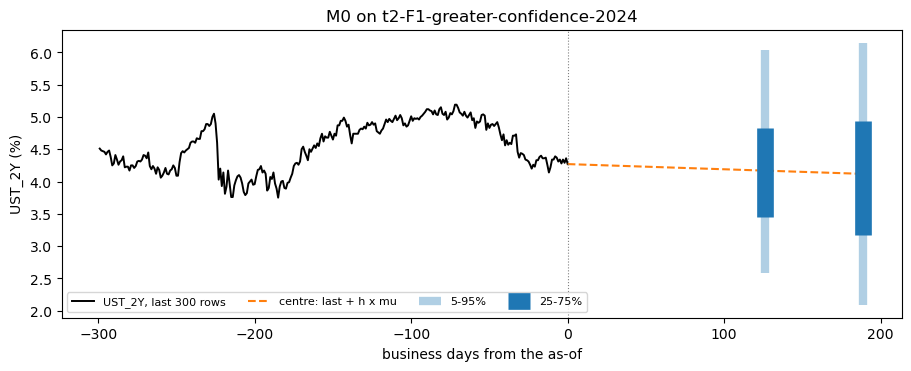

In [11]:
q = [0.05, 0.25, 0.5, 0.75, 0.95]
summary = pd.DataFrame({f"h = {h}": np.quantile(draws[:, i], q) for i, h in enumerate(horizons)},
                       index=["5%", "25%", "median", "75%", "95%"]).T
summary.insert(0, "centre", [centre[h] for h in horizons]); summary.insert(1, "sd", [np.sqrt(h * sigma2) for h in horizons])
display(summary)

fig, ax = plt.subplots(figsize=(9, 3.6), layout="constrained")
ax.plot(np.arange(-len(hist) + 1, 1), hist.value, color="black", lw=1.4, label=f"{asset}, last 300 rows")
ax.plot([0, h1, h2], [last, centre[h1], centre[h2]], color="tab:orange", lw=1.5, ls="--", label="centre: last + h x mu")
for i, h in enumerate(horizons):
    lo, q25, med, q75, hi = np.quantile(draws[:, i], q)
    ax.vlines(h, lo, hi, color="tab:blue", lw=6, alpha=.35, label="5-95%" if i == 0 else None)
    ax.vlines(h, q25, q75, color="tab:blue", lw=12, label="25-75%" if i == 0 else None)
ax.axvline(0, color="grey", lw=.8, ls=":")
ax.set_xlabel("business days from the as-of"); ax.set_ylabel(f"{asset} (%)"); ax.legend(loc="lower left", ncols=4, fontsize=8)
ax.set_title(f"M0 on {unit_id}"); plt.show()

## 9 — M0 in one table

| | M0 |
|---|---|
| history | the last 300 rows up to the as-of |
| steps | today − yesterday (a log-return unit uses the rows themselves); changes across a long gap dropped |
| centre at h | last value + h × mean step (**with drift**) |
| spread at h | sd × √h, with the plain sd of the 300 steps; no widen |
| shape | normal |
| horizons | one path: covariance min(h1, h2) × sigma² |
| several assets | the same, with the full covariance matrix of their steps on common dates |
| draws | 500, seed = crc32(unit id) |

Nothing in M0 is tuned: it is the same recipe on every unit.